In [2]:
import cajal.sample_swc
import cajal.swc


In [48]:
#dist matrix with only morphology and metadata SWCs
cajal.sample_swc.compute_icdm_all_euclidean(
    infolder = "/home/njay/cajal/Cajal_mouse_humans/data/only_metadata_swc",
    out_csv="../data/processed/mousehuman_100pts_euclidean_icdm.csv",
    preprocess=cajal.swc.preprocessor_eu(
        structure_ids=[1, 3,4],
        soma_component_only=False),
    n_sample=100,
    num_processes=8)  # num_processes can be set to the number of cores on your machine


100%|██████████████████████████████████████████████████████████████████████████████▉| 687/688 [8:06:35<00:42, 42.50s/it]


[]

In [49]:
import cajal.run_gw

cajal.run_gw.compute_gw_distance_matrix(
    "../data/processed/mousehuman_100pts_euclidean_icdm.csv",
    "../data/processed/mousehuman100pts_euclidean_GW_dmat.csv",
    num_processes=8)

  0%|          | 0/236328 [00:00<?, ?it/s]

(array([[ 0.        , 20.14217352, 27.30714013, ..., 51.03475505,
         11.54364492, 59.26578033],
        [20.14217352,  0.        , 25.06661623, ..., 36.54018091,
         23.89213788, 44.14154218],
        [27.30714013, 25.06661623,  0.        , ..., 45.53733946,
         24.51622228, 53.79947763],
        ...,
        [51.03475505, 36.54018091, 45.53733946, ...,  0.        ,
         53.14227655, 29.23162205],
        [11.54364492, 23.89213788, 24.51622228, ..., 53.14227655,
          0.        , 61.53493709],
        [59.26578033, 44.14154218, 53.79947763, ..., 29.23162205,
         61.53493709,  0.        ]]),
 None)

In [1]:
import plotly.io as pio
pio.renderers.default = 'iframe'

import cajal.utilities
import umap
import plotly.express

# Read GW distance matrix
cells, gw_dist_dict = cajal.utilities.read_gw_dists("../data/processed/mousehuman100pts_euclidean_GW_dmat.csv", header=True)
gw_dist = cajal.utilities.dist_mat_of_dict(gw_dist_dict)

# Compute UMAP representation
reducer = umap.UMAP(metric="precomputed", random_state=1)
embedding = reducer.fit_transform(gw_dist)

# Visualize UMAP
plotly.express.scatter(x=embedding[:,0],
                       y=embedding[:,1],
                       template="simple_white",
                       hover_name=[m + ".swc" for m in cells])



/home/njay/miniconda3/envs/morphoL/lib/python3.9/site-packages/umap/umap_.py:1857: UserWarning:

using precomputed metric; inverse_transform will be unavailable

/home/njay/miniconda3/envs/morphoL/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning:

n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [2]:
clusters = cajal.utilities.leiden_clustering(gw_dist, seed=1)
plotly.express.scatter(x=embedding[:,0],
                       y=embedding[:,1],
                       template="simple_white",
                       hover_name=[m + ".swc" for m in cells],
                       color = [str(m) for m in clusters])

In [3]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
cells_without_suffix = [specimen_id.replace('_transformed', '').replace('_upright', '').replace('_m', '') for specimen_id in cells]

# Filter metadata based on cells_without_suffix
metadata = pd.read_csv("../data/raw/Cajal_mousehuman_metadatav2.csv")

metadata.index = [str(m) for m in metadata["Specimen ID"]]
metadata = metadata.loc[cells_without_suffix]

fig = px.scatter(
    x=embedding[:, 0],
    y=embedding[:, 1],
    template="simple_white",
    hover_name=[m + ".swc" for m in metadata.index],  # Use metadata index for hover_name
    color=metadata["Dataset"], title="B) Mouse and Human Datasets labels", # Use "Dataset" column for color
    color_discrete_map={
        'Human Patchseq': 'red',
        'Old Gouwen': 'cyan',
        'New Patchseq': 'blue'
    } )
fig.show()


FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/Cajal_mousehuman_metadatav2.csv'

In [18]:
import pandas as pd
import plotly.express as px

import plotly.io as pio

# Plot using Plotly Express
fig = px.scatter(
    x=embedding[:, 0],
    y=embedding[:, 1],
    template="simple_white",
    hover_name= [m + ".swc" for m in cells_without_suffix],
    color=metadata["T type sub-class"],
    title="C) Human Subclass labels based UMAP"
)

# Show the plot
fig.show()


In [9]:
import cajal.laplacian_score
import numpy
import pandas
from scipy.spatial.distance import squareform

# Build indicator matrix
layers = numpy.unique(metadata["T type sub-class"])
indicator = (numpy.array(metadata["T type sub-class"])[:,None] == layers)*1

# Compute the Laplacian score
laplacian = pandas.DataFrame(cajal.laplacian_score.laplacian_scores(indicator,
                                       gw_dist,
                                       numpy.median(squareform(gw_dist)),
                                       permutations = 5000,
                                       covariates = None,
                                       return_random_laplacians = False)[0])
laplacian.index = layers

print(laplacian)

        feature_laplacians  laplacian_p_values  laplacian_q_values
Lamp5             0.909166            0.000200            0.000700
Pvalb             0.994904            0.001800            0.003149
Scnn1A            1.001786            0.469306            0.547524
Sncg              1.002662            0.744651            0.744651
Sst               0.984010            0.000200            0.000700
Vip               0.972184            0.000200            0.000700
Vipr2             1.000004            0.089582            0.125415


In [ ]:
#RANDOM FOREST CLASSIFIERS

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cell_type = numpy.array(metadata["T type sub-class"])

clf = RandomForestClassifier(n_estimators=100, random_state=1)
cv = StratifiedKFold(n_splits=5, shuffle=True)
accuracy = cross_val_score(clf, X=gw_dist, y=cell_type, cv=cv)

numpy.mean(accuracy)


/home/njay/miniconda3/envs/morphoL/lib/python3.9/site-packages/sklearn/model_selection/_split.py:737: UserWarning:

The least populated class in y has only 4 members, which is less than n_splits=5.



0.44481117105680734

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cell_type = numpy.array(metadata["Binary_Lamp5"])

clf = RandomForestClassifier(n_estimators=100, random_state=1)
cv = StratifiedKFold(n_splits=5, shuffle=True)
accuracy = cross_val_score(clf, X=gw_dist, y=cell_type, cv=cv)

numpy.mean(accuracy)


0.9447371204908496

Accuracy: 0.27184466019417475


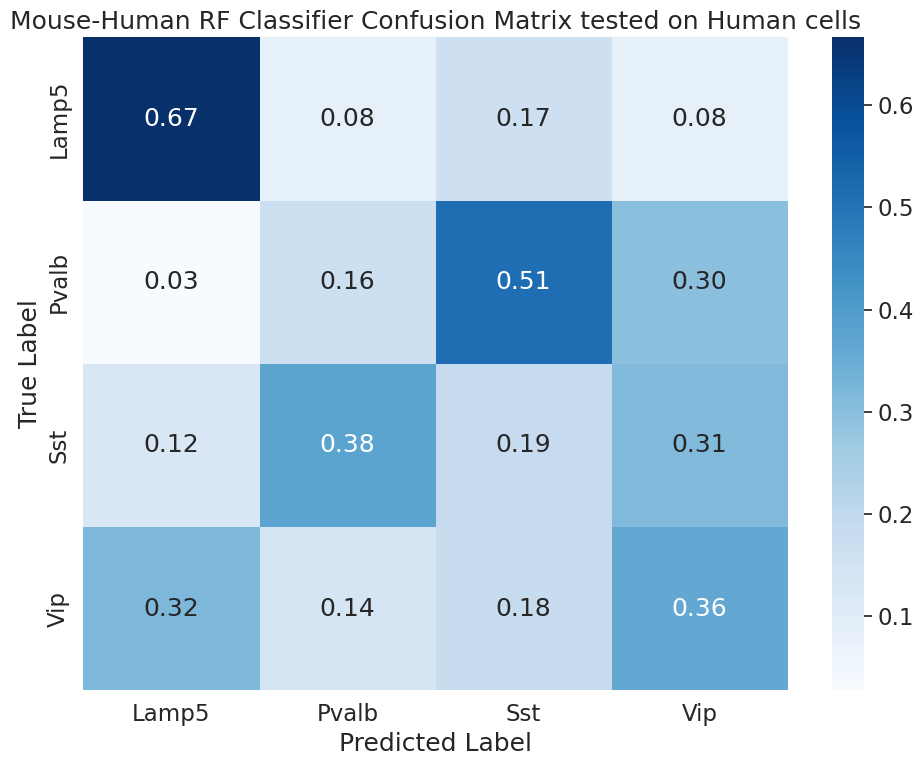

In [8]:
# Testing the Mouse based RF Classifier solely on Human Cells
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

X = gw_dist
y = metadata['T type sub-class']

mouse_type1_indices = metadata['Dataset'] == 'Old Gouwen'
mouse_type2_indices = metadata['Dataset'] == 'New Patchseq'
mouse_indices = mouse_type1_indices | mouse_type2_indices

human_indices = metadata['Dataset'] == 'Human Patchseq'

# Selecting data for train and test
X_mouse = X[mouse_indices]
y_mouse = y[mouse_indices]

X_human = X[human_indices]
y_human = y[human_indices]

# Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=0)
rf_classifier.fit(X_mouse, y_mouse)

# Predicting on human data
y_pred_human = rf_classifier.predict(X_human)
accuracy = accuracy_score(y_human, y_pred_human)
print('Accuracy:', accuracy)

# Get subclass names
subclass_names = np.unique(y_human)

# Confusion matrix
conf_mat = confusion_matrix(y_human, y_pred_human)
# normalise
conf_mat_percentage = conf_mat / conf_mat.sum(axis=1, keepdims=True)
# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns. set(font_scale=1.5)
sns.heatmap(conf_mat_percentage, annot=True, cmap='Blues', fmt='.2f', xticklabels=subclass_names, yticklabels=subclass_names)
plt.title('Mouse-Human RF Classifier Confusion Matrix tested on Human cells')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('Confusion Matrix for Mouse-Human RF Classifier (CAJAL) tested on Human cells')
plt.tight_layout()
plt.show()


Accuracy: 0.8446601941747572


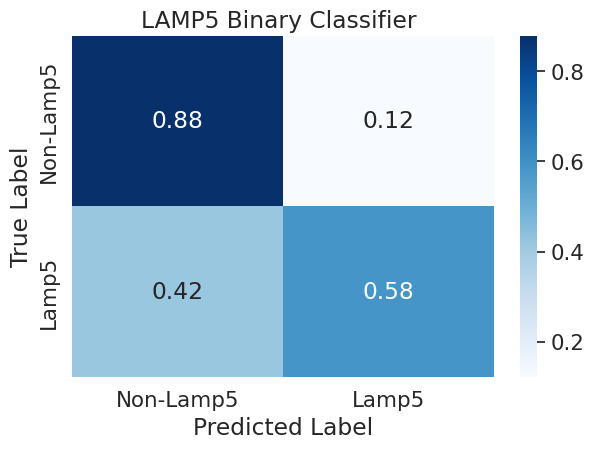

In [19]:
# LAMP5 Binary Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
X = gw_dist
y = metadata['Binary_Lamp5']

mouse_type1_indices = metadata['Dataset'] == 'Old Gouwen'
mouse_type2_indices = metadata['Dataset'] == 'New Patchseq'
mouse_indices = mouse_type1_indices | mouse_type2_indices

human_indices = metadata['Dataset'] == 'Human Patchseq'

# Selecting data for train and test
X_mouse = X[mouse_indices]
y_mouse = y[mouse_indices]

X_human = X[human_indices]
y_human = y[human_indices]

# Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=0)
rf_classifier.fit(X_mouse, y_mouse)

# Predicting on human data
y_pred_human = rf_classifier.predict(X_human)
accuracy = accuracy_score(y_human, y_pred_human)
print('Accuracy:', accuracy)

# Get subclass names
#subclass_names = np.unique(y_human)

subclass_names = ['Non-Lamp5', 'Lamp5']
# Confusion matrix
conf_mat = confusion_matrix(y_human, y_pred_human)
# normalise
conf_mat_percentage = conf_mat / conf_mat.sum(axis=1, keepdims=True)
# Plot
#plt.figure(figsize=(10, 8))
sns.set(font_scale=1.4)
sns.heatmap(conf_mat_percentage, annot=True, cmap='Blues', fmt='.2f', xticklabels=subclass_names, yticklabels=subclass_names)
#sns.heatmap(conf_mat, annot=True, cmap='GnBu', fmt='d', xticklabels=subclass_names, yticklabels=subclass_names)
plt.title('LAMP5 Binary Classifier ')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()

plt.savefig('Confusion Matrix:Binary RF Classifier Lamp5 subclass')

plt.show()


Accuracy without shuffling labels: 0.27184466019417475
Accuracy with shuffled labels: 0.2912621359223301


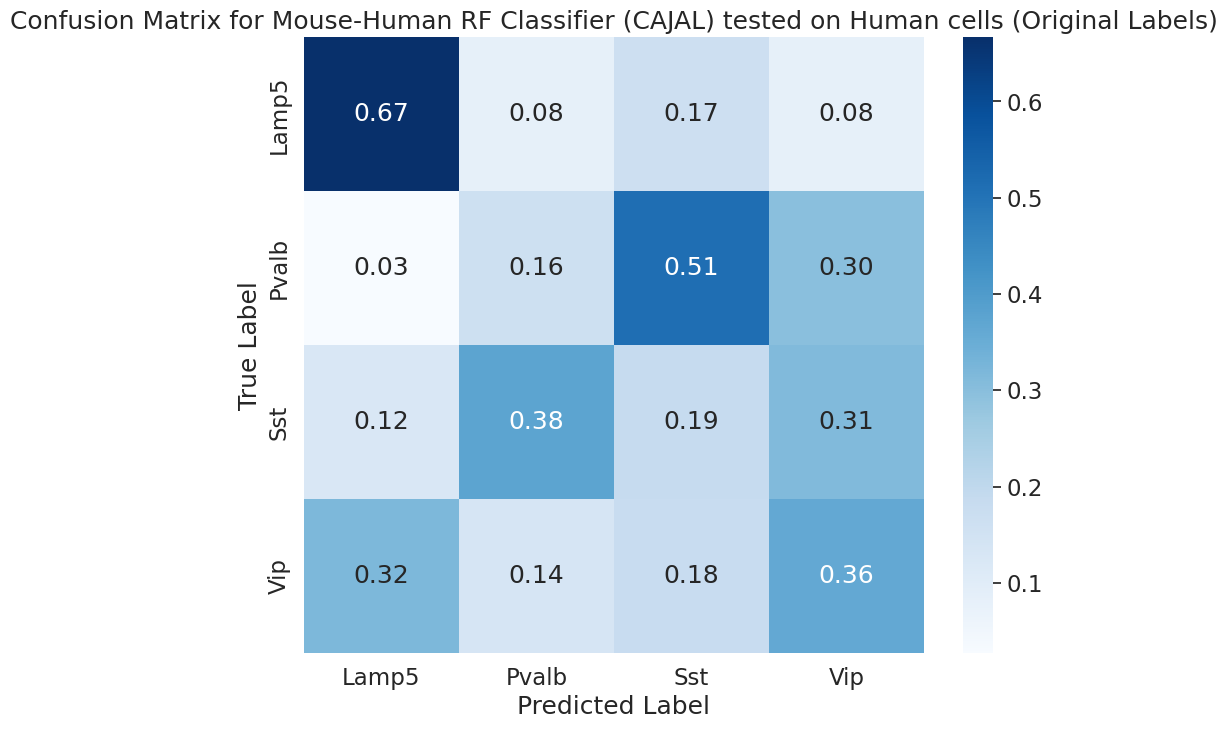

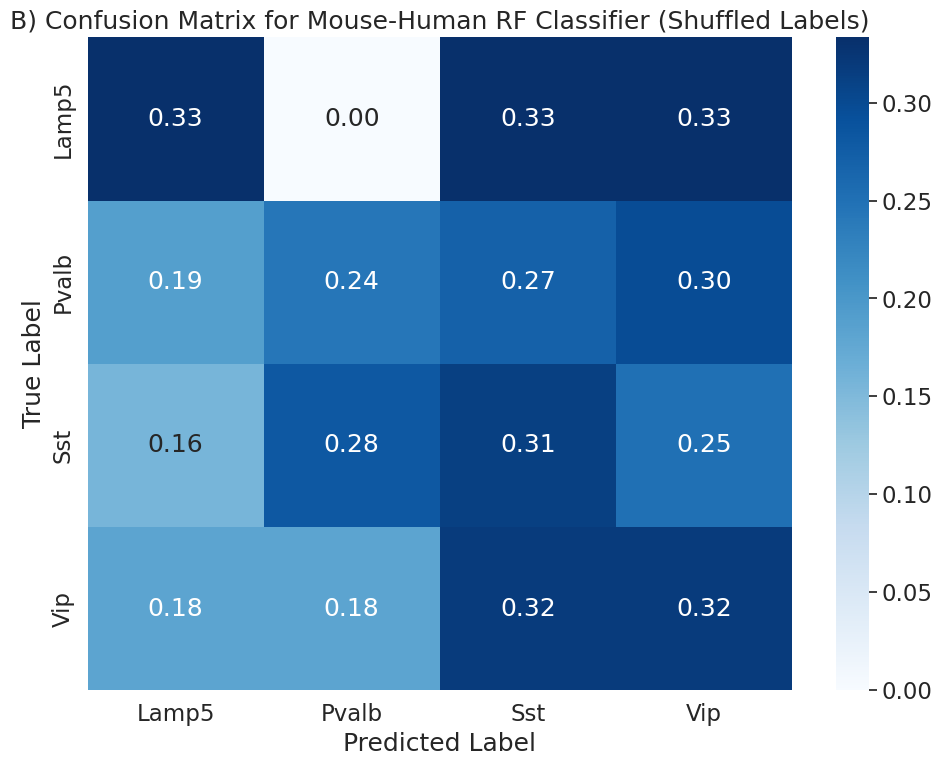

In [25]:
#Accuracy of RF classifier tested with Random Shuffling of Labels
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

X = gw_dist
y = metadata['T type sub-class']

mouse_type1_indices = metadata['Dataset'] == 'Old Gouwen'
mouse_type2_indices = metadata['Dataset'] == 'New Patchseq'
mouse_indices = mouse_type1_indices | mouse_type2_indices

human_indices = metadata['Dataset'] == 'Human Patchseq'

# Selecting data for train and test
X_mouse = X[mouse_indices]
y_mouse = y[mouse_indices]

X_human = X[human_indices]
y_human = y[human_indices]

# Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=0)
rf_classifier.fit(X_mouse, y_mouse)

# Predicting on human data
y_pred_human = rf_classifier.predict(X_human)
accuracy = accuracy_score(y_human, y_pred_human)
print('Accuracy without shuffling labels:', accuracy)
shuffled_y_human = np.random.permutation(y_human)

# Testing with shuffled labels
y_pred_human_shuffled = rf_classifier.predict(X_human)
accuracy_shuffled = accuracy_score(shuffled_y_human, y_pred_human_shuffled)
print('Accuracy with shuffled labels:', accuracy_shuffled)

# Get subclass names
subclass_names = np.unique(y_human)

# Confusion matrix for original labels
conf_mat = confusion_matrix(y_human, y_pred_human)
conf_mat_percentage = conf_mat / conf_mat.sum(axis=1, keepdims=True)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat_percentage, annot=True, cmap='Blues', fmt='.2f', xticklabels=subclass_names, yticklabels=subclass_names)
plt.title('Confusion Matrix for Mouse-Human RF Classifier (CAJAL) tested on Human cells (Original Labels)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Confusion matrix for shuffled labels
conf_mat_shuffled = confusion_matrix(shuffled_y_human, y_pred_human_shuffled)
conf_mat_percentage_shuffled = conf_mat_shuffled / conf_mat_shuffled.sum(axis=1, keepdims=True)
plt.figure(figsize=(10, 8))
sns. set(font_scale=1.5)
sns.heatmap(conf_mat_percentage_shuffled, annot=True, cmap='Blues', fmt='.2f', xticklabels=subclass_names, yticklabels=subclass_names)
plt.title('B) Confusion Matrix for Mouse-Human RF Classifier (Shuffled Labels)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('Confusion Matrix for Mouse-Human RF Classifier (CAJAL) tested on Human cells Shuffled Labels')
plt.show()
